In [ ]:
# performance testing for metapop1
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import pickle
from metapop_value_iteration import _act, build_optimal_controller_fully_observable
from metapop1 import metapop1
import numpy as np
import pandas as pd
from heuristic_policy_postRL2 import *

def avgperformance(env, config, policy_printout=False):
    device = torch.device('cpu')  # Force CPU usage
    policytype = config['policytype']
    num_episodes = config['num_episodes']
    if policytype == 0: # Value iteration
        print( 'policy type: value iteration')
        with open(f'./value_iteration/VI_controller_setting{config["VIenvid"]}.pkl', 'rb') as f:
            ctrl = pickle.load(f)
        Policy = ctrl['policy']
        # reinitiate the environment
        settings = ctrl['envinfo']
        print(settings)
        env = metapop1(settings)
    elif policytype == 1: # ppo
        print(f'policy type: PPO, seed: {config["pposeed"]}, paramset: {config["ppoparamset"]}')
        wd = f"./PPO_results/good_ones/seed{config['pposeed']}_paramid{config['ppoparamset']}"
        # re-initialize the environment
        if config['specificepi'] is None:
            with open(f'{wd}/config.txt', 'r') as f:
                lines = f.readlines()
            for line in lines:
                if 'envconfig' in line:
                    obsvarline = line
                    break
            # parse the dictionary string of envconfig and evaluate it to get the obsvars
            envconfigstr = obsvarline.split('envconfig: ')[1].strip()
            envconfigdict = eval(envconfigstr)
            env = metapop1(envconfigdict)

        # find filename that starts with bestPolicyNetwork
        if config['specificepi'] is None:
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyNetwork"):
                    model_path = os.path.join(wd, filename)
                    break
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyrms"):
                    rms_path = os.path.join(wd, filename)
                    break
            with open(rms_path, "rb") as f:
                rms = pickle.load(f)
        else:
            print(f"testing specific seed: {config['specificepi']}")
            model_path = f"{wd}/PolicyNetwork_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pt"
            rms_model_path = f"{wd}/rms_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pkl"
            with open(rms_model_path, "rb") as f:
                rms = pickle.load(f)

        Policy = torch.load(model_path, weights_only=False)
        # find filename that starts with bestPolicyrms

    elif policytype == 2: # heuristics
        if config['heuristics'] == 0:
            print( 'policy type: heuristics, no action')
        elif config['heuristics'] == 1:
            print( 'policy type: heuristics, full action')
        elif config['heuristics'] == 2:
            print( 'policy type: heuristics, random action')
        elif config['heuristics'] == 3:
            print( 'policy type: heuristics, supplement if X=0 or H=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 4:
            print( 'policy type: heuristics, supplement if X=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 5:
            print( 'policy type: heuristics, custom heuristics')
        elif config['heuristics'] == 6:
            print( 'policy type: heuristics, custom heuristics 2')
        elif config['heuristics'] == 7:
            print( 'policy type: heuristics, custom heuristics 3')
        elif config['heuristics'] == 8:
            print( 'policy type: heuristics, custom heuristics 4')
        elif config['heuristics'] == 9:
            heur = HeuristicPolicy(env.patchnum, env.settingID)
            print( 'policy type: heuristics, custom heuristics 5 (post RL heuristics)')
            
    rewards = []
    avgconnectivity = []
    avgeprob = []
    avgcprob = []
    occfraction = []
    goodHfraction = []
    survivaltime = []
    restore_fraction = []
    supp_fraction = []
    for i in range(num_episodes):
        obs, state = env.reset()
        input = obs.copy()
        if policytype == 1:
            input = rms.normalize(input)
        done = False
        ep_reward = 0
        avgconnectivity_per_episode = []
        avgeprob_per_episode = []
        avgcprob_per_episode = []
        occfraction_per_episode = []
        goodHfraction_per_episode = []
        survivaltime_per_episode = []
        restore_fraction_per_episode = []
        supp_fraction_per_episode = []
        tt=0
        while not done:
            if policytype == 0:
                action = _act(env, Policy, input)
            elif policytype == 1:
                with torch.no_grad():

                    tensorinput = torch.tensor(input, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
                    action = Policy.getaction(tensorinput, get_action_only=True)
                    action = torch.squeeze(action).cpu().detach().numpy()
            elif policytype == 2: # heuristics
                if config['heuristics'] == 0: # no action
                    action = np.zeros(env.aS_dim + env.aR_dim)
                elif config['heuristics'] == 1: # full action
                    aR = np.zeros(env.aR_dim)
                    rlen = min(env.kR, env.aR_dim)
                    aR[np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)] = 1
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    aS[np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 2: # random action
                    aR = np.zeros(env.aR_dim, dtype=int)
                    rlen = min(env.kR, env.aR_dim)
                    Ridx = np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)
                    aR[Ridx] = np.random.choice([0,1], size=rlen)
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    Sidx = np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)
                    aS[Sidx] = np.random.choice([0,1], size=slen)
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] in [3,4]: # supplement if X=0 or H=0 (if config=3, supplement only X=0 for config=4)and restore H=0's in the order of highest incoming weight sum.
                    aR = np.zeros(env.aR_dim, dtype=int)
                    aS = np.zeros(env.aS_dim, dtype=int)
                    X = env.state[:,env.oidx['X']] if env.dim2state == 1 else env.state[env.oidx['X']]
                    H = env.state[:,env.oidx['H']] if env.dim2state == 1 else env.state[env.oidx['H']]
                    incoming_weights = env.w.sum(axis=0)
                    if config['heuristics'] == 3:
                        sidx = np.where((X == 0) | (H == 0))[0]
                    else:
                        sidx = np.where(X == 0)[0]
                    aS[sidx] = 1
                    h0 = np.where(H == 0)[0]
                    if h0.size > 0:
                        h0_sorted = h0[np.argsort(incoming_weights[h0])[::-1]]
                        aR[h0_sorted[:env.kR]] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 5: # custom heuristics
                    ruletype = 1
                    action = env.heuristic_action()
                elif config['heuristics'] == 6: # custom heuristics 2
                    ruletype = 2
                    action = env.heuristic_action(ruletype=ruletype)
                elif config['heuristics'] == 7: # custom heuristics 3
                    ruletype = 3
                    action = env.heuristic_action(ruletype=ruletype)
                elif config['heuristics'] == 8: # custom heuristics 4
                    ruletype = 4
                    action = env.heuristic_action(ruletype=ruletype)
                elif config['heuristics'] == 9: # custom heuristics 5 (post RL heuristics)
                    ruletype = 5
                    action = env.heuristic_action(ruletype=ruletype)
                    #action = heur.act(env.obs.copy())
                

            tt += 1
            if policy_printout:
                print(f't: {input[env.oidx["t"][0]]},  X: {input[env.oidx["X"]]}, aS: {action[env.aidx["aS"]]}, H: {input[env.oidx["H"]]}, Z: {input[env.oidx["Z"]]}, aR: {action[env.aidx["aR"]]}')
            obs, reward, done, info = env.step(action)
            input = env.obs.copy()
            if policytype == 1:
                input = rms.normalize(input)
            ep_reward += reward
            avgconnectivity_per_episode.append(np.mean(info['connectivity']))
            avgeprob_per_episode.append(np.mean(info['extinction_prob']))
            avgcprob_per_episode.append(np.mean(info['colonization_prob']))

            occfraction_per_episode.append(np.mean(info['occupied_fraction']))
            goodHfraction_per_episode.append(np.mean(info['goodhabitat_fraction']))
            restore_fraction_per_episode.append(np.sum(action[0:env.patchnum])/env.patchnum)
            supp_fraction_per_episode.append(np.sum(action[env.patchnum:])/env.patchnum)
        avgconnectivity.append(np.mean(avgconnectivity_per_episode))
        avgeprob.append(np.mean(avgeprob_per_episode))
        avgcprob.append(np.mean(avgcprob_per_episode))
        occfraction.append(np.mean(occfraction_per_episode))
        goodHfraction.append(np.mean(goodHfraction_per_episode))
        survivaltime.append(tt)
        restore_fraction.append(np.mean(restore_fraction_per_episode))
        supp_fraction.append(np.mean(supp_fraction_per_episode))
        rewards.append(ep_reward)
        #if (i+1) % 100 == 0:
        #    print(f'Episode {i+1} done')
    summary = {'rewards': rewards, 'connectivity': avgconnectivity, 'extinction_prob': avgeprob, 'colonization_prob': avgcprob, 'occupied_fraction': occfraction, 'good_habitat_fraction': goodHfraction, 'survival_time': survivaltime, 'restore_fraction': restore_fraction, 'supp_fraction': supp_fraction}
    summary_df = pd.DataFrame(summary)
    
    print(f'patch num = {env.patchnum}')
    print(f'Average reward over {num_episodes} episodes: {np.mean(rewards):.2f}')
    print(f'Average connectivity: {np.mean(avgconnectivity):.2f}, Average extinction prob: {np.mean(avgeprob):.2f}, Average colonization prob: {np.mean(avgcprob):.2f}')
    print(f'Occupied fraction: Avg {np.mean(occfraction):.2f}, Std {np.std(occfraction):.2f}') 
    print(f'Good habitat fraction: Avg {np.mean(goodHfraction):.2f}, Std {np.std(goodHfraction):.2f}')
    print(f'Average survival time: {np.mean(survivaltime):.2f}')
    # add average in the first row of summary_df
    summary_df.loc[-1] = [np.mean(rewards), np.mean(avgconnectivity), np.mean(avgeprob), np.mean(avgcprob), np.mean(occfraction), np.mean(goodHfraction), np.mean(survivaltime), np.mean(restore_fraction), np.mean(supp_fraction)]
    summary_df.index = summary_df.index + 1  # shift index
    summary_df = summary_df.sort_index()  # sort by index
    # save as csv
    random_seed = np.random.randint(0, 100000000)
    summary_df.to_csv(f'./performance_summary/heur{ruletype}_performance_summary_n{env.settingID}.csv', index=False)

    return summary


# policytype: 0 for value iteration, 1 for ppo, 2 for heuristics
# n=10 low centrality -> seednum = 839394, paramid = 35, parid = 10, setid = 22

config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 9, 'num_episodes': 10000}# [37400,33200]
#for ii in np.arange(24,34):
for ii in [24:]:
    settings = {'settingID': ii}
    if type(config['specificepi']) == list:
        for seed in config['specificepi']:
            env = metapop1(settings)
            newconfig = config.copy()
            newconfig['specificepi'] = seed
            summary = avgperformance(env,config=newconfig, policy_printout=False)
    else:
        env = metapop1(settings)
        summary = avgperformance(env,config=config, policy_printout=False)





policy type: heuristics, custom heuristics 4
patch num = 10
Average reward over 10000 episodes: 5.25
Average connectivity: 1.55, Average extinction prob: 0.27, Average colonization prob: 0.17
Occupied fraction: Avg 0.76, Std 0.02
Good habitat fraction: Avg 0.77, Std 0.04
Average survival time: 30.00


In [ ]:
# performance testing for metapop1
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import pickle
from metapop_value_iteration import _act, build_optimal_controller_fully_observable
from metapop1 import metapop1
import numpy as np
import pandas as pd
from heuristic_policy_postRL2 import *

def avgperformance(env, config, policy_printout=False):
    device = torch.device('cpu')  # Force CPU usage
    policytype = config['policytype']
    num_episodes = config['num_episodes']
    if policytype == 0: # Value iteration
        print( 'policy type: value iteration')
        with open(f'./value_iteration/VI_controller_setting{config["VIenvid"]}.pkl', 'rb') as f:
            ctrl = pickle.load(f)
        Policy = ctrl['policy']
        # reinitiate the environment
        settings = ctrl['envinfo']
        print(settings)
        env = metapop1(settings)
    elif policytype == 1: # ppo
        print(f'policy type: PPO, seed: {config["pposeed"]}, paramset: {config["ppoparamset"]}')
        wd = f"./PPO_results/good_ones/seed{config['pposeed']}_paramid{config['ppoparamset']}"
        # re-initialize the environment
        if config['specificepi'] is None:
            with open(f'{wd}/config.txt', 'r') as f:
                lines = f.readlines()
            for line in lines:
                if 'envconfig' in line:
                    obsvarline = line
                    break
            # parse the dictionary string of envconfig and evaluate it to get the obsvars
            envconfigstr = obsvarline.split('envconfig: ')[1].strip()
            envconfigdict = eval(envconfigstr)
            env = metapop1(envconfigdict)

        # find filename that starts with bestPolicyNetwork
        if config['specificepi'] is None:
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyNetwork"):
                    model_path = os.path.join(wd, filename)
                    break
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyrms"):
                    rms_path = os.path.join(wd, filename)
                    break
            with open(rms_path, "rb") as f:
                rms = pickle.load(f)
        else:
            print(f"testing specific seed: {config['specificepi']}")
            model_path = f"{wd}/PolicyNetwork_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pt"
            rms_model_path = f"{wd}/rms_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pkl"
            with open(rms_model_path, "rb") as f:
                rms = pickle.load(f)

        Policy = torch.load(model_path, weights_only=False)
        # find filename that starts with bestPolicyrms

    elif policytype == 2: # heuristics
        if config['heuristics'] == 0:
            print( 'policy type: heuristics, no action')
        elif config['heuristics'] == 1:
            print( 'policy type: heuristics, full action')
        elif config['heuristics'] == 2:
            print( 'policy type: heuristics, random action')
        elif config['heuristics'] == 3:
            print( 'policy type: heuristics, supplement if X=0 or H=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 4:
            print( 'policy type: heuristics, supplement if X=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 5:
            print( 'policy type: heuristics, custom heuristics')
        elif config['heuristics'] == 6:
            print( 'policy type: heuristics, custom heuristics 2')
        elif config['heuristics'] == 7:
            print( 'policy type: heuristics, custom heuristics 3')
        elif config['heuristics'] == 8:
            print( 'policy type: heuristics, custom heuristics 4')
        elif config['heuristics'] == 9:
            heur = HeuristicPolicy(env.patchnum, env.settingID)
            print( 'policy type: heuristics, custom heuristics 5 (post RL heuristics)')
            
    rewards = []
    avgconnectivity = []
    avgeprob = []
    avgcprob = []
    occfraction = []
    goodHfraction = []
    survivaltime = []
    restore_fraction = []
    supp_fraction = []
    for i in range(num_episodes):
        obs, state = env.reset()
        input = obs.copy()
        if policytype == 1:
            input = rms.normalize(input)
        done = False
        ep_reward = 0
        avgconnectivity_per_episode = []
        avgeprob_per_episode = []
        avgcprob_per_episode = []
        occfraction_per_episode = []
        goodHfraction_per_episode = []
        survivaltime_per_episode = []
        restore_fraction_per_episode = []
        supp_fraction_per_episode = []
        tt=0
        while not done:
            if policytype == 0:
                action = _act(env, Policy, input)
            elif policytype == 1:
                with torch.no_grad():

                    tensorinput = torch.tensor(input, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
                    action = Policy.getaction(tensorinput, get_action_only=True)
                    action = torch.squeeze(action).cpu().detach().numpy()
            elif policytype == 2: # heuristics
                if config['heuristics'] == 0: # no action
                    action = np.zeros(env.aS_dim + env.aR_dim)
                elif config['heuristics'] == 1: # full action
                    aR = np.zeros(env.aR_dim)
                    rlen = min(env.kR, env.aR_dim)
                    aR[np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)] = 1
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    aS[np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 2: # random action
                    aR = np.zeros(env.aR_dim, dtype=int)
                    rlen = min(env.kR, env.aR_dim)
                    Ridx = np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)
                    aR[Ridx] = np.random.choice([0,1], size=rlen)
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    Sidx = np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)
                    aS[Sidx] = np.random.choice([0,1], size=slen)
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] in [3,4]: # supplement if X=0 or H=0 (if config=3, supplement only X=0 for config=4)and restore H=0's in the order of highest incoming weight sum.
                    aR = np.zeros(env.aR_dim, dtype=int)
                    aS = np.zeros(env.aS_dim, dtype=int)
                    X = env.state[:,env.oidx['X']] if env.dim2state == 1 else env.state[env.oidx['X']]
                    H = env.state[:,env.oidx['H']] if env.dim2state == 1 else env.state[env.oidx['H']]
                    incoming_weights = env.w.sum(axis=0)
                    if config['heuristics'] == 3:
                        sidx = np.where((X == 0) | (H == 0))[0]
                    else:
                        sidx = np.where(X == 0)[0]
                    aS[sidx] = 1
                    h0 = np.where(H == 0)[0]
                    if h0.size > 0:
                        h0_sorted = h0[np.argsort(incoming_weights[h0])[::-1]]
                        aR[h0_sorted[:env.kR]] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 5: # custom heuristics
                    action = env.heuristic_action()
                elif config['heuristics'] == 6: # custom heuristics 2
                    action = env.heuristic_action(ruletype=2)
                elif config['heuristics'] == 7: # custom heuristics 3
                    action = env.heuristic_action(ruletype=3)
                elif config['heuristics'] == 8: # custom heuristics 4
                    action = env.heuristic_action(ruletype=4)
                elif config['heuristics'] == 9: # custom heuristics 5 (post RL heuristics)
                    #action = env.heuristic_action(ruletype=5)
                    action = heur.act(env.obs.copy())
                

            tt += 1
            if policy_printout:
                print(f't: {input[env.oidx["t"][0]]},  X: {input[env.oidx["X"]]}, aS: {action[env.aidx["aS"]]}, H: {input[env.oidx["H"]]}, Z: {input[env.oidx["Z"]]}, aR: {action[env.aidx["aR"]]}')
            obs, reward, done, info = env.step(action)
            input = env.obs.copy()
            if policytype == 1:
                input = rms.normalize(input)
            ep_reward += reward
            avgconnectivity_per_episode.append(np.mean(info['connectivity']))
            avgeprob_per_episode.append(np.mean(info['extinction_prob']))
            avgcprob_per_episode.append(np.mean(info['colonization_prob']))

            occfraction_per_episode.append(np.mean(info['occupied_fraction']))
            goodHfraction_per_episode.append(np.mean(info['goodhabitat_fraction']))
            restore_fraction_per_episode.append(np.sum(action[0:env.patchnum])/env.patchnum)
            supp_fraction_per_episode.append(np.sum(action[env.patchnum:])/env.patchnum)
        avgconnectivity.append(np.mean(avgconnectivity_per_episode))
        avgeprob.append(np.mean(avgeprob_per_episode))
        avgcprob.append(np.mean(avgcprob_per_episode))
        occfraction.append(np.mean(occfraction_per_episode))
        goodHfraction.append(np.mean(goodHfraction_per_episode))
        survivaltime.append(tt)
        restore_fraction.append(np.mean(restore_fraction_per_episode))
        supp_fraction.append(np.mean(supp_fraction_per_episode))
        rewards.append(ep_reward)
        #if (i+1) % 100 == 0:
        #    print(f'Episode {i+1} done')
    summary = {'rewards': rewards, 'connectivity': avgconnectivity, 'extinction_prob': avgeprob, 'colonization_prob': avgcprob, 'occupied_fraction': occfraction, 'good_habitat_fraction': goodHfraction, 'survival_time': survivaltime, 'restore_fraction': restore_fraction, 'supp_fraction': supp_fraction}
    summary_df = pd.DataFrame(summary)
    
    print(f'patch num = {env.patchnum}')
    print(f'Average reward over {num_episodes} episodes: {np.mean(rewards):.2f}')
    print(f'Average connectivity: {np.mean(avgconnectivity):.2f}, Average extinction prob: {np.mean(avgeprob):.2f}, Average colonization prob: {np.mean(avgcprob):.2f}')
    print(f'Occupied fraction: Avg {np.mean(occfraction):.2f}, Std {np.std(occfraction):.2f}') 
    print(f'Good habitat fraction: Avg {np.mean(goodHfraction):.2f}, Std {np.std(goodHfraction):.2f}')
    print(f'Average survival time: {np.mean(survivaltime):.2f}')
    # add average in the first row of summary_df
    summary_df.loc[-1] = [np.mean(rewards), np.mean(avgconnectivity), np.mean(avgeprob), np.mean(avgcprob), np.mean(occfraction), np.mean(goodHfraction), np.mean(survivaltime), np.mean(restore_fraction), np.mean(supp_fraction)]
    summary_df.index = summary_df.index + 1  # shift index
    summary_df = summary_df.sort_index()  # sort by index
    # save as csv
    random_seed = np.random.randint(0, 100000000)
    summary_df.to_csv(f'./performance_summary/performance_summary_{random_seed}.csv', index=False)
    print(f'saved performance summary to ./performance_summary/performance_summary_{random_seed}.csv')

    return summary


# policytype: 0 for value iteration, 1 for ppo, 2 for heuristics
# n=10 low centrality -> seednum = 839394, paramid = 35, parid = 10, setid = 22

config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 7, 'num_episodes': 10000}# [37400,33200]
settings = {'settingID': 18}
if type(config['specificepi']) == list:
    for seed in config['specificepi']:
        env = metapop1(settings)
        newconfig = config.copy()
        newconfig['specificepi'] = seed
        summary = avgperformance(env,config=newconfig, policy_printout=False)
else:
    env = metapop1(settings)
    summary = avgperformance(env,config=config, policy_printout=False)





policy type: heuristics, custom heuristics 3
patch num = 5
Average reward over 10000 episodes: 5.46
Average connectivity: 1.52, Average extinction prob: 0.28, Average colonization prob: 0.16
Occupied fraction: Avg 0.75, Std 0.04
Good habitat fraction: Avg 0.74, Std 0.06
Average survival time: 29.74
saved performance summary to ./performance_summary/performance_summary_81196187.csv


In [2]:
# heuristics parameterization testing (coarse search)
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import pickle
from metapop_value_iteration import _act, build_optimal_controller_fully_observable
from metapop1 import metapop1
import numpy as np
import pandas as pd
from heuristic_policy_postRL2 import *

def avgperformance(env, config, policy_printout=False):
    device = torch.device('cpu')  # Force CPU usage
    policytype = config['policytype']
    num_episodes = config['num_episodes']
    if policytype == 0: # Value iteration
        print( 'policy type: value iteration')
        with open(f'./value_iteration/VI_controller_setting{config["VIenvid"]}.pkl', 'rb') as f:
            ctrl = pickle.load(f)
        Policy = ctrl['policy']
        # reinitiate the environment
        settings = ctrl['envinfo']
        print(settings)
        env = metapop1(settings)
    elif policytype == 1: # ppo
        print(f'policy type: PPO, seed: {config["pposeed"]}, paramset: {config["ppoparamset"]}')
        wd = f"./PPO_results/good_ones/seed{config['pposeed']}_paramid{config['ppoparamset']}"
        # re-initialize the environment
        if config['specificepi'] is None:
            with open(f'{wd}/config.txt', 'r') as f:
                lines = f.readlines()
            for line in lines:
                if 'envconfig' in line:
                    obsvarline = line
                    break
            # parse the dictionary string of envconfig and evaluate it to get the obsvars
            envconfigstr = obsvarline.split('envconfig: ')[1].strip()
            envconfigdict = eval(envconfigstr)
            env = metapop1(envconfigdict)

        # find filename that starts with bestPolicyNetwork
        if config['specificepi'] is None:
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyNetwork"):
                    model_path = os.path.join(wd, filename)
                    break
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyrms"):
                    rms_path = os.path.join(wd, filename)
                    break
            with open(rms_path, "rb") as f:
                rms = pickle.load(f)
        else:
            print(f"testing specific seed: {config['specificepi']}")
            model_path = f"{wd}/PolicyNetwork_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pt"
            rms_model_path = f"{wd}/rms_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pkl"
            with open(rms_model_path, "rb") as f:
                rms = pickle.load(f)

        Policy = torch.load(model_path, weights_only=False)
        # find filename that starts with bestPolicyrms

    elif policytype == 2: # heuristics
        if config['heuristics'] == 0:
            print( 'policy type: heuristics, no action')
        elif config['heuristics'] == 1:
            print( 'policy type: heuristics, full action')
        elif config['heuristics'] == 2:
            print( 'policy type: heuristics, random action')
        elif config['heuristics'] == 3:
            print( 'policy type: heuristics, supplement if X=0 or H=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 4:
            print( 'policy type: heuristics, supplement if X=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 5:
            print( 'policy type: heuristics, custom heuristics')
        elif config['heuristics'] == 6:
            print( 'policy type: heuristics, custom heuristics 2')
        elif config['heuristics'] == 7:
            print( 'policy type: heuristics, custom heuristics 3')
        elif config['heuristics'] == 8:
            print( 'policy type: heuristics, custom heuristics 4')
        elif config['heuristics'] == 9:
            heur = HeuristicPolicy(env.patchnum, env.settingID)
            print( 'policy type: heuristics, custom heuristics 5 (post RL heuristics)')
            
    rewards = []
    avgconnectivity = []
    avgeprob = []
    avgcprob = []
    occfraction = []
    goodHfraction = []
    survivaltime = []
    restore_fraction = []
    supp_fraction = []
    for i in range(num_episodes):
        obs, state = env.reset()
        input = obs.copy()
        if policytype == 1:
            input = rms.normalize(input)
        done = False
        ep_reward = 0
        avgconnectivity_per_episode = []
        avgeprob_per_episode = []
        avgcprob_per_episode = []
        occfraction_per_episode = []
        goodHfraction_per_episode = []
        survivaltime_per_episode = []
        restore_fraction_per_episode = []
        supp_fraction_per_episode = []
        tt=0
        while not done:
            if policytype == 0:
                action = _act(env, Policy, input)
            elif policytype == 1:
                with torch.no_grad():

                    tensorinput = torch.tensor(input, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
                    action = Policy.getaction(tensorinput, get_action_only=True)
                    action = torch.squeeze(action).cpu().detach().numpy()
            elif policytype == 2: # heuristics
                if config['heuristics'] == 0: # no action
                    action = np.zeros(env.aS_dim + env.aR_dim)
                elif config['heuristics'] == 1: # full action
                    aR = np.zeros(env.aR_dim)
                    rlen = min(env.kR, env.aR_dim)
                    aR[np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)] = 1
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    aS[np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 2: # random action
                    aR = np.zeros(env.aR_dim, dtype=int)
                    rlen = min(env.kR, env.aR_dim)
                    Ridx = np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)
                    aR[Ridx] = np.random.choice([0,1], size=rlen)
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    Sidx = np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)
                    aS[Sidx] = np.random.choice([0,1], size=slen)
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] in [3,4]: # supplement if X=0 or H=0 (if config=3, supplement only X=0 for config=4)and restore H=0's in the order of highest incoming weight sum.
                    aR = np.zeros(env.aR_dim, dtype=int)
                    aS = np.zeros(env.aS_dim, dtype=int)
                    X = env.state[:,env.oidx['X']] if env.dim2state == 1 else env.state[env.oidx['X']]
                    H = env.state[:,env.oidx['H']] if env.dim2state == 1 else env.state[env.oidx['H']]
                    incoming_weights = env.w.sum(axis=0)
                    if config['heuristics'] == 3:
                        sidx = np.where((X == 0) | (H == 0))[0]
                    else:
                        sidx = np.where(X == 0)[0]
                    aS[sidx] = 1
                    h0 = np.where(H == 0)[0]
                    if h0.size > 0:
                        h0_sorted = h0[np.argsort(incoming_weights[h0])[::-1]]
                        aR[h0_sorted[:env.kR]] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 5: # custom heuristics
                    action = env.heuristic_action()
                elif config['heuristics'] == 6: # custom heuristics 2
                    action = env.heuristic_action(ruletype=2)
                elif config['heuristics'] == 7: # custom heuristics 3
                    action = env.heuristic_action(ruletype=3)
                elif config['heuristics'] == 8: # custom heuristics 4
                    action = env.heuristic_action(ruletype=4)
                elif config['heuristics'] == 9: # custom heuristics 5 (post RL heuristics)
                    action = heur.act(env.obs.copy())
                

            tt += 1
            if policy_printout:
                print(f't: {input[env.oidx["t"][0]]},  X: {input[env.oidx["X"]]}, aS: {action[env.aidx["aS"]]}, H: {input[env.oidx["H"]]}, Z: {input[env.oidx["Z"]]}, aR: {action[env.aidx["aR"]]}')
            obs, reward, done, info = env.step(action)
            input = env.obs.copy()
            if policytype == 1:
                input = rms.normalize(input)
            ep_reward += reward
            avgconnectivity_per_episode.append(np.mean(info['connectivity']))
            avgeprob_per_episode.append(np.mean(info['extinction_prob']))
            avgcprob_per_episode.append(np.mean(info['colonization_prob']))

            occfraction_per_episode.append(np.mean(info['occupied_fraction']))
            goodHfraction_per_episode.append(np.mean(info['goodhabitat_fraction']))
            restore_fraction_per_episode.append(np.sum(action[0:env.patchnum])/env.patchnum)
            supp_fraction_per_episode.append(np.sum(action[env.patchnum:])/env.patchnum)
        avgconnectivity.append(np.mean(avgconnectivity_per_episode))
        avgeprob.append(np.mean(avgeprob_per_episode))
        avgcprob.append(np.mean(avgcprob_per_episode))
        occfraction.append(np.mean(occfraction_per_episode))
        goodHfraction.append(np.mean(goodHfraction_per_episode))
        survivaltime.append(tt)
        restore_fraction.append(np.mean(restore_fraction_per_episode))
        supp_fraction.append(np.mean(supp_fraction_per_episode))
        rewards.append(ep_reward)
        #if (i+1) % 100 == 0:
        #    print(f'Episode {i+1} done')
    summary = {'rewards': rewards, 'connectivity': avgconnectivity, 'extinction_prob': avgeprob, 'colonization_prob': avgcprob, 'occupied_fraction': occfraction, 'good_habitat_fraction': goodHfraction, 'survival_time': survivaltime, 'restore_fraction': restore_fraction, 'supp_fraction': supp_fraction}
    summary_df = pd.DataFrame(summary)
    
    print(f'patch num = {env.patchnum}')
    print(f'Average reward over {num_episodes} episodes: {np.mean(rewards):.2f}')
    print(f'Average connectivity: {np.mean(avgconnectivity):.2f}, Average extinction prob: {np.mean(avgeprob):.2f}, Average colonization prob: {np.mean(avgcprob):.2f}')
    print(f'Occupied fraction: Avg {np.mean(occfraction):.2f}, Std {np.std(occfraction):.2f}') 
    print(f'Good habitat fraction: Avg {np.mean(goodHfraction):.2f}, Std {np.std(goodHfraction):.2f}')
    print(f'Average survival time: {np.mean(survivaltime):.2f}')
    # add average in the first row of summary_df
    summary_df.loc[-1] = [np.mean(rewards), np.mean(avgconnectivity), np.mean(avgeprob), np.mean(avgcprob), np.mean(occfraction), np.mean(goodHfraction), np.mean(survivaltime), np.mean(restore_fraction), np.mean(supp_fraction)]
    summary_df.index = summary_df.index + 1  # shift index
    summary_df = summary_df.sort_index()  # sort by index
    # save as csv
    #random_seed = np.random.randint(0, 100000000)
    #summary_df.to_csv(f'./performance_summary/performance_summary_{random_seed}.csv', index=False)

    return summary


# heur2 parameterization testing
#config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 7, 'num_episodes': 10000}# [37400,33200]
#settings = {'settingID': 23}
#eprobthvals = np.linspace(0.1,0.9,9)
#cprobthvals = np.linspace(0.1,0.9,9)
#perf_summ = np.zeros((len(eprobthvals), len(cprobthvals)))
#for i, eprobthval in enumerate(eprobthvals):
#    for j, cprobthval in enumerate(cprobthvals):
#        env = metapop1(settings)
#        env.eprob_th = eprobthval
#        env.cprob_th = cprobthval
#        print(f'testing eprob_th: {eprobthval}, cprob_th: {cprobthval}')
#        summary = avgperformance(env,config=config, policy_printout=False)
#        perf_summ[i, j] = np.mean(summary['rewards'])
#print('maximum avg performance is', np.max(perf_summ), 'with eprob_th:', eprobthvals[np.argmax(perf_summ)//len(cprobthvals)], 'and cprob_th:', cprobthvals[np.argmax(perf_summ)%len(cprobthvals)])

# heur 3 parameterization testing
#config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 7, 'num_episodes': 3}# [37400,33200]
#settings = {'settingID': 18}
#
#s_thvals = np.linspace(0.5,5.5,6) # 0.5,1.5,2.5,...
#r_thvals = np.linspace(2.4,2.9,6) # 2.4,2.5,...,2.9
#w_extvals = [0.5,1,1.5,2,4] # 0.5,1.0,1.5,2.0,2.5
#w_colvals = [0.5,1,1.5,2,4] # 0.5,1.0,1.5,2.0,2.5
#perf_summ = np.zeros((len(s_thvals), len(r_thvals), len(w_extvals), len(w_colvals)))
#for i, s_thval in enumerate(s_thvals):
#    for j, r_thval in enumerate(r_thvals):
#        for k, w_extval in enumerate(w_extvals):
#            for l, w_colval in enumerate(w_colvals):
#                env = metapop1(settings)
#                env.s_th = s_thval
#                env.r_th = r_thval
#                env.w_ext = w_extval
#                env.w_col = w_colval
#                print(f'testing s_th: {s_thval}, r_th: {r_thval}, w_ext: {w_extval}, w_col: {w_colval}')
#                summary = avgperformance(env, config=config, policy_printout=False)
#                perf_summ[i, j, k, l] = np.mean(summary['rewards'])
#
#best_idx = np.unravel_index(np.argmax(perf_summ), perf_summ.shape)
#print('maximum avg performance is', np.max(perf_summ),
#      'with s_th:', s_thvals[best_idx[0]],
#      'r_th:', r_thvals[best_idx[1]],
#      'w_ext:', w_extvals[best_idx[2]],
#      'and w_col:', w_colvals[best_idx[3]])

# heur 4 parameterization testing
config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 8, 'num_episodes': 10}# [37400,33200]
settings = {'settingID': 20}

w1vals = np.linspace(0.1,1.0,10) # 0.1, 0.2 , ... ,1.0
tau_suppvals = np.linspace(0.0,2,9) # 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0
 

perf_summ = np.zeros((len(w1vals), len(tau_suppvals)))
for i, w1val in enumerate(w1vals):
    for j, tau_suppval in enumerate(tau_suppvals):
        env = metapop1(settings)
        env.w1 = w1val
        env.w2 = 1.0 - w1val
        env.tau_supp = tau_suppval
        print(f'testing w1: {w1val}, tau_supp: {tau_suppval}')
        summary = avgperformance(env, config=config, policy_printout=False)
        perf_summ[i, j] = np.mean(summary['rewards'])

best_idx = np.unravel_index(np.argmax(perf_summ), perf_summ.shape)
print('maximum avg performance is', np.max(perf_summ),
      'with w1:', w1vals[best_idx[0]],
      'and tau_supp:', tau_suppvals[best_idx[1]])

testing w1: 0.1, tau_supp: 0.0
policy type: heuristics, custom heuristics 4
patch num = 10
Average reward over 10 episodes: 6.38
Average connectivity: 1.55, Average extinction prob: 0.26, Average colonization prob: 0.17
Occupied fraction: Avg 0.77, Std 0.02
Good habitat fraction: Avg 0.79, Std 0.04
Average survival time: 30.00
testing w1: 0.1, tau_supp: 0.25
policy type: heuristics, custom heuristics 4
patch num = 10
Average reward over 10 episodes: 4.96
Average connectivity: 1.54, Average extinction prob: 0.28, Average colonization prob: 0.17
Occupied fraction: Avg 0.75, Std 0.01
Good habitat fraction: Avg 0.76, Std 0.04
Average survival time: 30.00
testing w1: 0.1, tau_supp: 0.5
policy type: heuristics, custom heuristics 4
patch num = 10
Average reward over 10 episodes: 5.16
Average connectivity: 1.53, Average extinction prob: 0.27, Average colonization prob: 0.17
Occupied fraction: Avg 0.75, Std 0.03
Good habitat fraction: Avg 0.76, Std 0.04
Average survival time: 30.00
testing w1: 

In [3]:
# Refined heur 4 parameterization testing (setting 18)
# Broad sweep best (setting 18) was near: s_th=2.5, r_th=2.4, w_ext=4, w_col=0.5
config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 8, 'num_episodes': 1000}
settings = {'settingID': 21}
w1vals = np.linspace(0.85, 1.0, 16) # 0.85, 0.86, ..., 1.0
tau_suppvals = np.linspace(0.0, 0.3, 16) # 0.0, 0.02, ..., 0.3

total_tests = len(w1vals) * len(tau_suppvals)
print(f'Running {total_tests} parameter combinations with {config["num_episodes"]} episodes each...')

perf_summ = np.zeros((len(w1vals), len(tau_suppvals)))
for i, w1val in enumerate(w1vals):
    for j, tau_suppval in enumerate(tau_suppvals):
        env = metapop1(settings)
        env.w1 = w1val
        env.w2 = 1.0 - w1val
        env.tau_supp = tau_suppval
        print(f'Testing combination {i*len(tau_suppvals)+j+1}/{total_tests}: w1={w1val:.3f}, tau_supp={tau_suppval:.3f}')
        summary = avgperformance(env, config=config, policy_printout=False)
        perf_summ[i, j] = np.mean(summary['rewards'])

best_idx = np.unravel_index(np.argmax(perf_summ), perf_summ.shape)
print('Maximum average performance is', np.max(perf_summ),
        'with w1:', w1vals[best_idx[0]],
        'and tau_supp:', tau_suppvals[best_idx[1]])


Running 256 parameter combinations with 1000 episodes each...
Testing combination 1/256: w1=0.850, tau_supp=0.000
policy type: heuristics, custom heuristics 4
patch num = 20
Average reward over 1000 episodes: 4.93
Average connectivity: 1.55, Average extinction prob: 0.26, Average colonization prob: 0.17
Occupied fraction: Avg 0.76, Std 0.02
Good habitat fraction: Avg 0.79, Std 0.02
Average survival time: 30.00
Testing combination 2/256: w1=0.850, tau_supp=0.020
policy type: heuristics, custom heuristics 4
patch num = 20
Average reward over 1000 episodes: 4.98
Average connectivity: 1.55, Average extinction prob: 0.26, Average colonization prob: 0.17
Occupied fraction: Avg 0.76, Std 0.02
Good habitat fraction: Avg 0.79, Std 0.02
Average survival time: 30.00
Testing combination 3/256: w1=0.850, tau_supp=0.040
policy type: heuristics, custom heuristics 4
patch num = 20
Average reward over 1000 episodes: 4.88
Average connectivity: 1.55, Average extinction prob: 0.26, Average colonization pr

In [ ]:
# Refined heur 3 parameterization testing (setting 18)
# Broad sweep best (setting 18) was near: s_th=2.5, r_th=2.4, w_ext=4, w_col=0.5
config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 7, 'num_episodes': 1000}
settings = {'settingID': 18}

# Focus around the new best region from setting 18 output
s_thvals = np.array([2.0, 2.5, 3.0])
r_thvals = np.array([2.4, 2.5, 2.6])
w_extvals = [2.0, 4.0]
w_colvals = [0.5, 1.0, 1.5]

total_tests = len(s_thvals) * len(r_thvals) * len(w_extvals) * len(w_colvals)
print(f'Running {total_tests} parameter combinations with {config["num_episodes"]} episodes each...')

perf_summ = np.zeros((len(s_thvals), len(r_thvals), len(w_extvals), len(w_colvals)))
for i, s_thval in enumerate(s_thvals):
    for j, r_thval in enumerate(r_thvals):
        for k, w_extval in enumerate(w_extvals):
            for l, w_colval in enumerate(w_colvals):
                env = metapop1(settings)
                env.s_th = s_thval
                env.r_th = r_thval
                env.w_ext = w_extval
                env.w_col = w_colval
                print(f'testing s_th: {s_thval}, r_th: {r_thval}, w_ext: {w_extval}, w_col: {w_colval}')
                summary = avgperformance(env, config=config, policy_printout=False)
                perf_summ[i, j, k, l] = np.mean(summary['rewards'])

best_idx = np.unravel_index(np.argmax(perf_summ), perf_summ.shape)
print('maximum avg performance is', np.max(perf_summ),
      'with s_th:', s_thvals[best_idx[0]],
      'r_th:', r_thvals[best_idx[1]],
      'w_ext:', w_extvals[best_idx[2]],
      'and w_col:', w_colvals[best_idx[3]])

In [6]:
import torch
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda build:", torch.version.cuda)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu118
cuda available: True
cuda build: 11.8
gpu: NVIDIA GeForce RTX 4070 SUPER


In [2]:
print(perf_summ)

[[-21.633149  -24.3621136 -25.4192654 -25.4312768 -25.4314506 -25.416828
  -25.424844  -25.4383388 -25.4424828]
 [  0.9380954   3.449555    3.5017728   3.538021    3.5259316   3.4881942
    3.5569806   3.5180602   3.5504246]
 [  3.1932654   3.9604768   3.7532694   3.7903322   3.7572478   3.7625762
    3.840268    3.822046    3.8109818]
 [  3.1594722   3.9552554   3.7941282   3.7691368   3.7716888   3.7878262
    3.7982964   3.7913888   3.787907 ]
 [  3.177479    3.92328     3.7831966   3.8126236   3.8122114   3.7945126
    3.7782096   3.762008    3.7765424]
 [  3.269532    4.372694    4.3913486   4.403431    4.423605    4.3878174
    4.4253984   4.3937502   4.4404642]
 [  3.6687278   4.790822    4.7652526   4.7650078   4.7719932   4.7626412
    4.7735552   4.7533434   4.7277712]
 [  3.662431    4.7919956   4.7298464   4.7497624   4.7706166   4.747779
    4.736845    4.7693792   4.7679178]
 [  3.6610068   4.7836294   4.7423028   4.7170656   4.7294186   4.7764678
    4.7731724   4.758620

(array([  34.,  284.,  933., 2247., 2911., 2304., 1008.,  242.,   33.,
           4.]),
 array([-2.56 , -0.563,  1.434,  3.431,  5.428,  7.425,  9.422, 11.419,
        13.416, 15.413, 17.41 ]),
 <BarContainer object of 10 artists>)

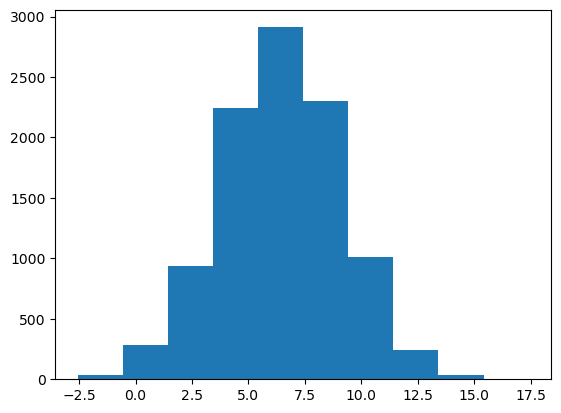

In [20]:
import os 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib.pyplot as plt

plt.hist(summary['rewards'])